In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import importlib

import generate
importlib.reload(generate)

from generate import ShapeGenerator

device = "cuda" if torch.cuda.is_available() else "cpu"
shape_generator = ShapeGenerator()

print("Using device:", device)

Using device: cpu


In [5]:
shapes_8 = {
    "circle": {"shape": "circle", "num_points": 80, "percentage": 0.125},
    "triangle": {"shape": "triangle", "num_points": 90, "percentage": 0.125},
    "hexagon": {"shape": "hexagon", "num_points": 96, "percentage": 0.125},
    "star_5": {"shape": "star", "num_points": 100, "n_tips": 5, "inner_radius": 0.45, "percentage": 0.125},
    "star_6": {"shape": "star", "num_points": 120, "n_tips": 6, "inner_radius": 0.50, "percentage": 0.125},
    "star_8": {"shape": "star", "num_points": 160, "n_tips": 8, "inner_radius": 0.55, "percentage": 0.125},
    "star_10": {"shape": "star", "num_points": 200, "n_tips": 10, "inner_radius": 0.60, "percentage": 0.125},
    "star_12": {"shape": "star", "num_points": 240, "n_tips": 12, "inner_radius": 0.65, "percentage": 0.125},
}

transform_cfg = {
    "translation_range": [-2.0, 2.0],
    "scale_range": [0.4, 1.2],
    "rotation_range": [0.0, 360.0],
}

/Users/giorgiopanizzutti/Desktop/EPFL_Local/REINFORCEMENT LEARNING/progettoRL/rl-mesh-deformation/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


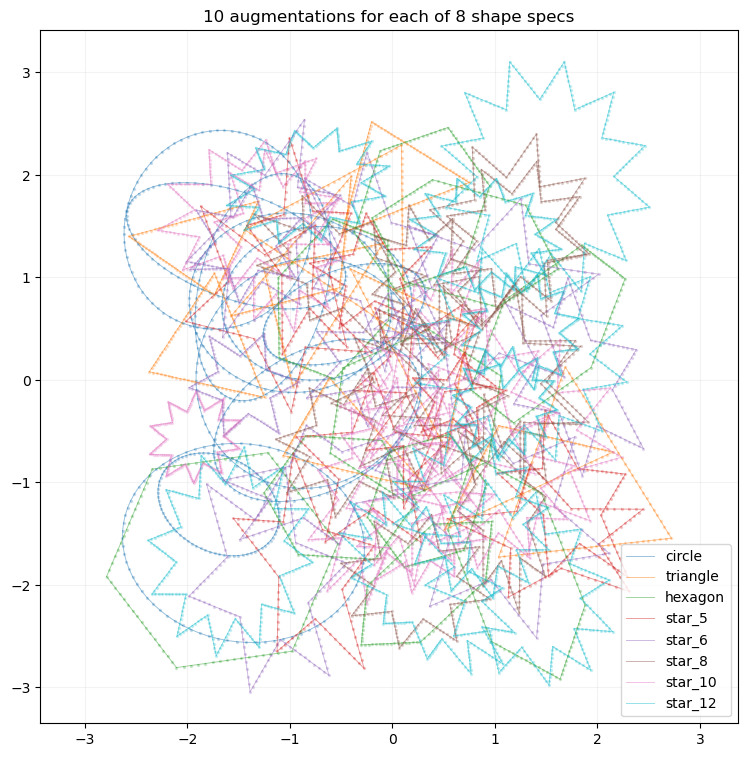

In [6]:
num_aug = 10

mixture = shape_generator.generate_mixture_batch_torch(
    shapes=shapes_8,
    transform_cfg=transform_cfg,
    samples_per_shape=num_aug,
    seed=123,
    device=device,
)

shape_colors = {
    "circle": "tab:blue",
    "triangle": "tab:orange",
    "hexagon": "tab:green",
    "star_5": "tab:red",
    "star_6": "tab:purple",
    "star_8": "tab:brown",
    "star_10": "tab:pink",
    "star_12": "tab:cyan",
}

fig, ax = plt.subplots(figsize=(9, 9))

for shape_name, batch in mixture.items():
    points, edges = batch.to_arrays(max_samples=num_aug)
    color = shape_colors[shape_name]

    first_label = True

    for i in range(num_aug):
        p = points[i]
        label = shape_name if first_label else None

        for e in edges:
            ax.plot(
                p[e, 0],
                p[e, 1],
                color=color,
                alpha=0.45,
                linewidth=0.7,
                label=label,
            )
            label = None

        ax.scatter(
            p[:, 0],
            p[:, 1],
            color=color,
            s=2,
            alpha=0.2,
        )

        first_label = False

ax.axis("equal")
ax.grid(alpha=0.15)
ax.legend()
ax.set_title(f"{num_aug} augmentations for each of 8 shape specs")
plt.show()

In [7]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

from generate import ShapeGenerator

def load_shard_points(shape_dir, shard_name="shard_000000.pt", device="cpu"):
    base_path = os.path.join(shape_dir, "base_shape.pt")
    shard_path = os.path.join(shape_dir, shard_name)

    base = torch.load(base_path, map_location=device)
    shard = torch.load(shard_path, map_location=device)

    base_points = base["base_points"].to(device)
    edges = base["edges"].to(device)

    if "points" in shard:
        points = shard["points"].to(device)
    else:
        points = ShapeGenerator.transform_points_torch(
            base_points=base_points,
            translation=shard["translation"].to(device),
            linear_matrix=shard["linear_matrix"].to(device),
        )

    return points, edges, base, shard

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

shape_dir = "generated_dataset/03_star_5"

points, edges, base, shard = load_shard_points(
    shape_dir=shape_dir,
    shard_name="shard_000000.pt",
    device=device,
)

print("Loaded from:", shape_dir)
print("points:", points.shape)
print("edges:", edges.shape)
print("base shape:", base["shape"])
print("base params:", base["params"])
print("shard keys:", shard.keys())

Loaded from: generated_dataset/03_star_5
points: torch.Size([4096, 60, 2])
edges: torch.Size([60, 2])
base shape: star
base params: {'n_tips': 5, 'inner_radius': 0.45}
shard keys: dict_keys(['translation', 'linear_matrix', 'spec_idx'])
